# Feature analysis — method + worked example: rolling Kyle's λ (adverse-selection / impact slope)

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy the template notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** (§3). The data
loading, the checks, and the plots adapt on their own.

**The feature here** is **Kyle's λ** — the *price-impact slope*: how much byb's mid moves per unit of
*signed* trade flow (buy volume minus sell volume). It is the classic adverse-selection coefficient from
Kyle (1985): in a market with informed traders, price moves *linearly* in the net order flow, and the
slope λ is how much each unit of net buying pushes the price. A **rising** λ means the book is fragile —
each trade drags the mid further — so larger continuing moves follow. We compute it as a **rolling
regression slope** on the trade clock, per venue, and ask which venue's flow has the larger impact (the
information venue) and which byb outcome it predicts.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the code really computes what we think it does (bit-exact vs an independent build).
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo of "the
  market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what time-scale*.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`. (Note: `λ_ev` is byb's mid-move *rate* yardstick — a different object from the
feature *Kyle's λ* in this notebook, which is an impact slope. Same Greek letter, unrelated.)

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime
and you want it gone, dividing by the yardstick is **one option** for removing it (only *when applicable*).
Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`) but **updated between trades**. They use
one fixed span, `YARDSTICK_N`. (`σ_ev` is the exp-weighted RMS of byb's *actual* mid-moves — read as an
`E/W` ratio so the many non-move trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb
move-count `W` ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here,
they live on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed**:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973; Ané & Geman, 2000): returns over a fixed clock-time window look messy,
but become well-behaved once you condition on the *number* of events.

Two questions recur below: does a feature's *signed* value predict the move (price head), and does its
*magnitude* predict how many moves come (rate head)? Those are diagnostics — the model is fed the
**signed** feature for *both* heads, and the rate head learns the magnitude on its own.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all. (Kyle's λ is built **per venue** — byb's
  own signed flow *and* okx's and bin's, each regressed against byb's mid — precisely so we can ask which
  venue's flow has the bigger impact, without privileging one.)
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. For a
  poolable feature, first check per-exchange vs single vs pooled across time-scales (§9).
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it
  needs it* — measure first. (Kyle's λ *has units*, so we expect it to need it — but we **measure** the
  scale gate before deciding, §2/§5.)
- **Don't invent your own vol/rate scale.** When you do normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol).
- **Don't ship a feature without the oracle** (§4) matching a dead-simple independent version.
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother — the regression-moment EMAs,
  `σ_ev`, `λ_ev` — is an exponential moving average **decayed once per trade-timestamp** (`α = 2/(span+1)`)
  yet **updated on every live event between trades**, **never** a wall-clock average and **never** a
  hard/boxcar window. That keeps the whole state **O(1)** and bit-identical online vs offline.
- **Do treat all records sharing a timestamp as ONE event, not a sequence.** A burst of trades stamped at
  the *exact same instant* did not arrive in an order — they are **one event**: sum their signed flow,
  apply byb's net mid-move, then advance the clock **once**. Imposing an order on a single instant invents
  motion that never happened — phantom intra-instant round-trips — which fabricates flow and inflates the
  regression moments.
- **Do always read the *freshest* value — never freeze on the last trade's.** An EMA decays once per
  trade-timestamp, but its *read* must use the latest data.
- **Do read a sparse flow as a per-event mean / moment.** Kyle's λ is built from two flow EMAs — the
  cross-moment `EMA(flow·Δlogmid)` and the second moment `EMA(flow²)` — each a sum over trade intervals,
  decayed every trade. The *ratio* of the two is the regression slope, and dividing one EMA by the other
  cancels the common decay/warm-up factor (exactly like `σ_ev`'s `E/W`), so the slope is well-defined from
  the first intervals.
- **Do test against both heads — but feed both the *signed* feature.** Check whether the signed feature
  predicts *direction* (price head) and whether its *magnitude* predicts *intensity* (rate head). In the
  model, feed the **signed** feature to *both* heads.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future).
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with the scale gate — never assume it.** A usable feature reads the
  *same* in calm and wild markets; the test is its **measured scale across volatility buckets** (§5), a
  **hard** gate (want < ~3×). Kyle's λ is a regression *slope* with units of log-price per signed-qty, so
  it *could* drift with the regime — but a slope is a *ratio* of two co-moving moments, which *might*
  cancel the regime. **Measure, don't assume** (§5 does, and decides raw-vs-normalised on the number).

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.

| | |
|---|---|
| **what** | the rolling price-impact slope λ = (byb mid-move per unit of *signed* trade flow), per venue |
| **feeds** | primarily the **rate head** (a rising λ ⇒ a fragile book ⇒ more/larger continuing moves); a signed-impact read for the price head is checked too |
| **predicts** | byb's mid-price 100 ms from now — *intensity* first, *direction* as a secondary check |

**The idea.** Kyle (1985): with informed traders in the book, the mid moves linearly in the **net order
flow** `q` (signed volume — buys minus sells), `Δmid ≈ λ · q`, and the slope **λ** is the *price impact*
of one unit of net buying. We estimate λ as a **rolling regression slope** on the trade clock:

`λ = EMA(signed_flow · Δlog mid) / (EMA(signed_flow²) + ε)`

— the textbook least-squares slope of byb's mid-move on signed flow, with both moments exp-weighted on the
trade clock. We compute one λ per venue: byb's own flow vs byb's mid (own-book impact), and **okx's** and
**bin's** flow vs byb's mid (cross-venue impact — does trading *there* move byb's price?).

**Why it should work.** λ is an **adverse-selection / liquidity-fragility gauge**. When λ is high, the
book is thin or informed flow is active, so each trade drags the mid further and **more (and larger)
moves follow** — that's the rate-head edge. Its *sign* reads the recent impact direction (a price-head
check). And comparing **λ_okx vs λ_byb** localises *where* impact is largest — the venue whose flow most
moves byb's price is the **information venue**.

**What would disprove it.** No predictive power at any time-scale for either head, or power that vanishes
once we account for how volatile/active the market is (meaning it was only tracking the regime).

> **No fixed leader.** We build λ the *same way for every venue and keep them all*; the cross-venue
> comparison (§6/§9) is exactly how we let the data say which venue's flow leads — never hard-coded.

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates on every event in between**. Two choices decide whether the
EMA is even *correct*, and a wrong choice fails **silently**.

**Choice 1 — which EMA, and how you read it** (`boba.ema`). Kyle's λ is a **ratio of two sparse flow
EMAs** — the cross-moment `EMA(flow·Δlogmid)` and the second moment `EMA(flow²)`, each a sum over trade
intervals decayed once per trade. Both legs share the same per-trade decay, so their **ratio** (the slope)
is self-normalising — the common `α`-warm-up and decay factor cancels, exactly like `σ_ev`'s `E/W`. So
each leg is a plain trade-clock **`EventEMA`** (one `step` per trade interval) and the feature reads
`cross / (second + ε)`.

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). The regression moments are injected **once per trade-timestamp**: at each trade-timestamp we form
that interval's signed flow `q` (the net signed volume of the trades stamped there) and byb's mid-move
`Δlogmid` over the interval, and push the sample `(q·Δlogmid, q²)` into the two EMAs, *then* decay. A
timestamp with no trades for a given venue contributes `q = 0` (a genuine zero-flow interval — it adds
nothing to either moment), so the slope is unbiased.

| push rule | what it weights / measures | use for |
|---|---|---|
| once per trade-timestamp (net signed flow over the interval) | a **per-interval regression moment** | Kyle's λ legs |
| every trade print separately | imposes a phantom order on simultaneous prints — fabricates flow | — (WRONG) |

The trap: treat the N simultaneous prints of one sweeping order as N intervals and you invent N−1 fake
flow/move pairs — inflating both regression moments and biasing the slope. Simultaneous prints are **one**
interval. The §4 oracle enforces this.

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking at the future.

**Measured on the trade clock** — we count progress in *trades* (one tick per trade-timestamp on any
exchange — simultaneous prints are one tick) rather than in clock-seconds. The byb mid-move `Δlogmid` over
an interval and the signed flow `q` over that interval are paired at each trade-timestamp; the EMAs decay
once per tick.

**Comparable across calm and wild markets** — here we **do not assume**. Kyle's λ is a regression *slope*
with units (log-price per signed-qty), so it *could* simply be larger when the market is volatile. But a
slope is a *ratio* of two moments that both grow with the regime, so the regime *might* cancel. §5
**measures** the scale across volatility buckets and decides raw-vs-normalised on the number — never
assumed.

Put it together:

**2a — The shape** (the whole idea, in one line):

`λ = EMA(signed_flow · Δlog mid) / (EMA(signed_flow²) + ε)`

the least-squares slope of byb's mid-move on signed flow, both moments exp-weighted on the trade clock.
A small `ε` (a tiny fraction of the typical `EMA(flow²)`) keeps the slope finite when a venue has had
almost no flow. Stop here and you have the feature — the rest is making each piece correct.

**2b — The EMAs we use, and how they update** (applying the two choices above):

- **The two regression-moment legs** — `C = EMA(q·Δlogmid)` and `S = EMA(q²)` — are each a plain
  **`EventEMA`** on the trade clock. At every trade-timestamp we form the interval's net signed flow `q`
  (signed by the aggressor: a trade that **lifts the ask** is a +qty buy, one that **hits the bid** is a
  −qty sell, via `io._trade_lifts_ask` so bin-spot's inverted convention is handled — though here all
  legs are perps) and byb's `Δlogmid` over the interval, push `(q·Δlogmid, q²)` into `(C, S)`, then decay
  both once. `λ = C / (S + ε)` is read at the **last committed trade tick ≤ the anchor** — unlike the
  template's forward-filled gap, λ is *not* read live between trades: it is **frozen at the last trade tick**
  (the C/S legs are pure `EventEMA`s with no live front), which is *more* conservative, never a leak. The
  `ε` here is a **fixed global constant** (a tiny fraction of the block-median `q²`, §3) — a hyperparameter,
  not a causal estimate, and ~1e-6 of typical `S` so it only bites when a venue goes near-silent (§4 / §8).
- **`σ_ev` and `λ_ev`** (the yardsticks) are the template's `E/W` `KernelMeanEMA` flows over byb's
  mid-moves, span `YARDSTICK_N` — used for the targets, the controls, and (if §5 says so) the normaliser.

§3 builds exactly this; §4 re-derives it from raw events one at a time and confirms it bit-exact.

The cell below loads the data, builds the shared trade clock, and computes **both yardsticks** as `E/W`
flows on that clock, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block, _trade_lifts_ask

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict (and whose mid the impact is measured on)
OTHERS      = ["bin", "okx"]                      # other venues — each one's signed flow gives a cross-venue λ vs byb
# freshest mid per exchange (for the TARGET and controls). byb/okx use merged_levels; bin MUST use front_levels
# (merged_levels is DISALLOWED for bin perp in boba.io — it raises). This is policy, not tuning.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
SPANS       = [50, 200, 500, 2000, 5000]         # λ EMA spans to sweep (the lookback family — Kyle's λ is a single-EMA-pair slope, so ONE span N per member)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): a trade-tick EMA (α=2/(N+1))
EPS_FRAC    = 1e-6                                # ε in λ = C/(S+ε), as a fraction of the median EMA(flow²) (keeps the slope finite when flow ~ 0)
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each exchange's mid-price stream (rows arrive in time order) — for the TARGET, the impact Δlogmid, and the controls
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("bin", "byb", "okx")}

# load each venue's SIGNED trade flow: +qty if the trade lifted the ask (buy), -qty if it hit the bid (sell)
def load_signed(ex):
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "aggressor", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))           # drop bad prc=qty=0 prints
    rx = td["rx_time"].cast(pl.Int64).to_numpy(); q = td["qty"].to_numpy()
    lifts = _trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy())  # True = lifted ask = aggressive BUY (venue-aware)
    return rx, np.where(lifts, q, -q)                                    # signed volume: +buy, -sell
sflow = {ex: load_signed(ex) for ex in ("bin", "byb", "okx")}

# the trade clock: one tick per trade-TIMESTAMP. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_prints = np.concatenate([sflow[ex][0] for ex in ("bin", "byb", "okx")])
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

def mid_on_clock(ex):                              # causal: each exchange's most-recent mid at-or-before every clock tick
    rx, mid = mids[ex]
    return mid[np.clip(np.searchsorted(rx, merged_ts, "right") - 1, 0, len(mid) - 1)]

# byb's log-mid on the clock, and Δlogmid over each interval ENDING at tick k (the impact the flow is regressed against)
log_mid_byb = np.log(mid_on_clock("byb"))
dlm = np.empty(n_ticks); dlm[0] = 0.0; dlm[1:] = np.diff(log_mid_byb)   # byb mid-move over the interval ending at tick k

# --- the yardsticks (σ_ev, λ_ev): react to every byb mid-move, decay once per trade. Identical to the template. ---
byb_rx0, byb_mid0 = mids["byb"]                                                   # raw byb merged mid stream
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update (final mid)
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2                                       # move times + squared returns
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, src_rx, val, span):   # EWMA of `val` over an EVENT stream `src_rx`, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, src_rx, "left")                              # trades strictly before each event (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the event stream (the partial epoch)
    partial = cs[np.searchsorted(src_rx, anchors, "right")] - cs[np.searchsorted(src_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_rx, mv_r2, span)                  # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, mv_rx, np.ones(mv_r2.size), span)   # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second (the RATE yardstick — NOT the feature)
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades


## 2c. The signed-flow / impact moments — built once per venue on the clock

Now the new pieces: per venue, aggregate the **signed trade flow** to the merged trade clock (sum the
signed volume of all that venue's prints stamped at each tick — simultaneous prints are one interval), and
pair it with byb's `Δlogmid` over the interval. That gives, per tick, `(q, q·Δlogmid, q²)`. We then take a
plain trade-clock EMA of `q·Δlogmid` (the cross-moment `C`) and of `q²` (the second moment `S`), and read
`λ = C / (S + ε)`. The same vectorized EMA machine serves every venue and every span.

In [2]:
# per-venue signed flow aggregated to the merged clock: q_k = net signed volume of that venue's prints at tick k
def flow_on_clock(ex):
    rx, sq = sflow[ex]
    idx = np.searchsorted(merged_ts, rx)            # exact tick index (every trade rx_time is a merged_ts tick by construction)
    f = np.zeros(n_ticks); np.add.at(f, idx, sq)    # sum simultaneous prints into ONE interval flow (records sharing a ts are one event)
    return f
flow = {ex: flow_on_clock(ex) for ex in ("bin", "byb", "okx")}
print("signed flow per venue (q per tick):  " + "  ".join(f"{ex}: std {flow[ex].std():.2f}" for ex in ("byb", "okx", "bin")))

# the two regression-moment products per venue, per tick: cross = q·Δlogmid, second = q²
cross = {ex: flow[ex] * dlm for ex in ("bin", "byb", "okx")}     # q·Δlogmid  (numerator sample)
sq2   = {ex: flow[ex] ** 2  for ex in ("bin", "byb", "okx")}     # q²         (denominator sample)
# ε per venue: a tiny fraction of the median q² so the slope is finite when flow ~ 0.
# HONEST DISCLOSURE (finding #3/#4): ε is a FIXED GLOBAL CONSTANT — it uses the block-median q² (so it is
# NOT strictly causal; it peeks at the whole block) but it is just ONE number, a hyperparameter, not a
# per-anchor estimate. At EPS_FRAC=1e-6 it is ~6 orders BELOW typical S, so it does NOT meaningfully floor
# the denominator: when a venue goes near-silent S decays toward 0 and λ=C/(S+ε) blows up (the kurt≈263 fat
# tail §8 measures). We keep EPS_FRAC=1e-6 as the SHIPPED raw atom because the headline metric is a rank-IC,
# which is IMMUNE to that tail (Spearman ignores the magnitude of the blow-ups) — but any LEVEL-based use of
# λ must regularise harder (raise EPS_FRAC to ~1e-3 of median q², printed below) or robust-z+clip (§8). We
# print BOTH so the trade-off is on the page; the shipped feature uses EPS (1e-6).
EPS  = {ex: EPS_FRAC * np.median(sq2[ex][sq2[ex] > 0]) for ex in ("bin", "byb", "okx")}    # SHIPPED ε (1e-6×median q²)
EPS3 = {ex: 1e-3    * np.median(sq2[ex][sq2[ex] > 0]) for ex in ("bin", "byb", "okx")}    # heavier floor (1e-3×median q²) — for reference only
print("ε per venue (SHIPPED, 1e-6 × median q²):  " + "  ".join(f"{ex}: {EPS[ex]:.3e}" for ex in ("byb", "okx", "bin")))
print("  vs typical S≈median q²:               " + "  ".join(f"{ex}: {np.median(sq2[ex][sq2[ex]>0]):.3e}" for ex in ("byb", "okx", "bin"))
      + "   (ε is ~1e-6 of S — negligible except on near-silent venues; rank-IC is immune, level-use is not)")

def _ema_tick(x, span):                             # plain trade-clock EMA: one decay+inject per tick (the C and S legs)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)

signed flow per venue (q per tick):  byb: std 10.88  okx: std 13.21  bin: std 12.58
ε per venue (SHIPPED, 1e-6 × median q²):  byb: 1.960e-08  okx: 6.812e-08  bin: 1.011e-07
  vs typical S≈median q²:               byb: 1.960e-02  okx: 6.812e-02  bin: 1.011e-01   (ε is ~1e-6 of S — negligible except on near-silent venues; rank-IC is immune, level-use is not)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in §4 — a streaming version that
does constant work per trade (no growing buffers). They have to agree.

We lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; adjacent 100 ms
outcome windows still overlap ~50%, which is why §5's walk-forward gate uses an embargo), read byb's
actual move over the next 100 ms (the price-head target, in `σ_ev` units) and its move-count (the rate-head
target), and compute λ at each grid point, per venue.

In [3]:
# evaluation grid (causal) + forward targets
WARMUP = 5 * max(YARDSTICK_N, max(SPANS))   # = 50000: enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor (λ is read at this committed tick)
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both yardsticks at each grid point (span YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (σ-units)

# the λ legs (C, S) are committed-per-trade EMAs; we read λ at the last committed tick <= each anchor (causal).
_C_cache, _S_cache = {}, {}
def _legs(ex, span):
    key = (ex, span)
    if key not in _C_cache:
        _C_cache[key] = _ema_tick(cross[ex], span)[tick_at_anchor]
        _S_cache[key] = _ema_tick(sq2[ex],  span)[tick_at_anchor]
    return _C_cache[key], _S_cache[key]
def kyle_lambda(ex, span):                         # Kyle's λ from venue `ex`'s signed flow vs byb's mid: C/(S+ε)
    C, S = _legs(ex, span)
    return C / (S + EPS[ex])                       # regression slope: log-price impact per unit signed flow
print(f"grid: {len(anchor_ts):,} anchors")
print("sample λ(byb, 500) median:", f"{np.nanmedian(kyle_lambda('byb', 500)):.3e}",
      " λ(okx, 500) median:", f"{np.nanmedian(kyle_lambda('okx', 500)):.3e}")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors
sample λ(byb, 500) median: 8.774e-08  λ(okx, 500) median: 1.302e-09


## 4. Check the code is right — the oracle (an independent streaming build)

**Non-negotiable.** Reproduce the feature with a second, **dead-simple, independent** implementation and
confirm the two agree on real data, **bit-exact**. The oracle is a plain O(1) state machine you push **raw
events** into one at a time — `on_mid(...)` for a byb merged-mid update (to track byb's mid), `on_trade(...)`
for a trade on any venue (to accumulate that venue's signed flow) — reading the current λ per venue from
`value()`. State is two scalar EMAs per venue (the `C` and `S` legs) plus byb's previous log-mid. No buffers,
no history.

**It imports NO production helper** — not `boba.ema`, not `lfilter`. Its only primitive is a six-line inline
`_ScalarEMA` (the standard `ema = (1-α)·ema + α·value` recursion, `α = 2/(span+1)`, `y[-1]=0` start),
reimplemented from the *written* EMA convention alone — exactly what a fresh reader given only "a plain
trade-clock EMA, one decay-and-inject per event" would write. §3 instead drives the same recursion through
`scipy.signal.lfilter`; the two sharing **no code** yet agreeing bit-exact is what makes this a genuine check
of the lfilter path, not a copy of it.

**The design (shares no code with §3):**
- Fed **only raw events** in rx-time order. byb's mid comes straight from its **merged_levels** stream
  (the same fused mid the analysis uses, so no re-fusion drift) — every merged row updates the current mid.
  It tracks byb's previous *committed* (last-trade) log-mid itself and forms `Δlogmid` when a trade lands.
- Events sharing a **timestamp are one event**: the driver applies them all (byb mid rows overwrite to the
  latest mid at that ns; each venue's trades **add into** that venue's running signed-flow accumulator),
  then calls **`refresh()` once** — which, if a trade landed, forms byb's `Δlogmid` over the interval
  (current mid − last-committed mid), injects `(q·Δlogmid, q²)` per venue into that venue's two legs, then
  decays **all** legs **once**. Simultaneous prints are one interval, one decay.
- `value()` returns `C/(S+ε)` per venue at the instant it's read.

We feed the **whole raw stream** — byb's merged-mid updates and **every** venue's trades — into one builder
and read all three λ at each grid anchor. If the online build reproduces §3's vectorized λ on real data to
floating-point precision, both are right.

**Coverage (finding #2): the shipped span, a long span, the WHOLE block.** The headline feature ships at
**N=50** (the rate-head pick for every venue), and the family sweeps up to N=5000. So we validate **both**
the shipped **N=50** and a long **N=5000**, for **all three venues**, by running two `LiveKyleLambda`
instances side-by-side in one pass — and we stream the **entire block** (all ~8 M raw events, no cutoff),
reading at a **uniform subsample of the full 1.7 M-anchor grid** (every k-th anchor, spanning warm-up to
end). The earlier 40k-prefix / single-span check only ever saw converged state on 2 % of the grid; this
exercises the recursion at the α actually shipped, across the whole block including the freshly-warm region.

In [4]:
import math
# INDEPENDENT ORACLE — shares NO code with §3 and imports NO production helper (no boba.ema, no lfilter).
# The single primitive is this dead-simple scalar EMA, reimplemented inline from the written convention alone
# (α = 2/(span+1), recursion ema = (1-α)·ema + α·value, started from the y[-1]=0 convention, nan before the
# first step). A fresh reader given only "a plain trade-clock EMA, one decay-and-inject per event" would write
# exactly this — that is the point of the oracle. §3 instead uses scipy.signal.lfilter; the two must still agree
# bit-exact, which is the real check that the lfilter recursion computes the feature we describe.
class _ScalarEMA:
    __slots__ = ("a", "ema", "started")
    def __init__(self, span):
        self.a = 2.0 / (span + 1.0); self.ema = 0.0; self.started = False
    def step(self, value):                                       # one decay-and-inject: ema <- (1-α)·ema + α·value
        self.ema = (1.0 - self.a) * self.ema + self.a * value; self.started = True
    def value(self):                                            # current EMA; nan until the first step
        return self.ema if self.started else float("nan")

class LiveKyleLambda:
    # Pure feature state machine for Kyle's λ per venue = EMA(q·Δlogmid)/(EMA(q²)+ε). Each venue has TWO scalar EMA legs
    # (cross C, second S). on_mid sets byb's current mid (from merged_levels — the SAME mid the analysis reads); on_trade
    # ADDS into that venue's signed-flow accumulator; refresh() (once per timestamp) forms byb's Δlogmid over the interval,
    # injects (q·Δlogmid, q²) per venue, then decays ALL legs once — but only if a trade landed (one decay per trade-ts).
    # State is O(1), all scalar — two _ScalarEMA legs per venue + byb's current and last-committed log-mid.
    def __init__(self, venues, span, eps):
        self.venues = list(venues); self.eps = dict(eps)
        self.legC = {v: _ScalarEMA(span) for v in self.venues}      # cross-moment leg C = EMA(q·Δlogmid)
        self.legS = {v: _ScalarEMA(span) for v in self.venues}      # second-moment leg S = EMA(q²)
        self.cur_lm = None                                          # byb's current log-mid (latest merged row, this/last ts)
        self.prev_lm = None                                         # byb's log-mid as of the LAST trade-tick (the Δlogmid baseline)
        self.flow_acc = {v: 0.0 for v in self.venues}               # this-timestamp signed-flow accumulator per venue
        self.was_trade_present = False                              # did any trade land this timestamp? -> one decay

    def on_mid(self, mid):                                        # byb merged-mid row -> overwrite the current mid (latest at this ns wins)
        self.cur_lm = math.log(mid)

    def on_trade(self, venue, signed_qty):                       # a trade -> ADD signed flow into this ts's accumulator; flag the ts as traded
        self.flow_acc[venue] += signed_qty
        self.was_trade_present = True

    def refresh(self):                                           # ONE per TIMESTAMP: form Δlogmid, inject per venue, decay once if a trade landed
        traded, self.was_trade_present = self.was_trade_present, False
        if traded and self.cur_lm is not None:
            dlm = 0.0 if self.prev_lm is None else (self.cur_lm - self.prev_lm)   # byb mid-move over the interval ending now
            for v in self.venues:
                q = self.flow_acc[v]
                self.legC[v].step(q * dlm)                       # _ScalarEMA.step = decay-and-inject the cross-moment sample
                self.legS[v].step(q * q)                         # ... and the second-moment sample
            self.prev_lm = self.cur_lm                           # the Δlogmid baseline advances only on a trade-tick
        for v in self.venues: self.flow_acc[v] = 0.0             # consume the accumulator either way

    def value(self):                                            # λ per venue: C/(S+ε), read live
        out = {}
        for v in self.venues:
            C, S = self.legC[v].value(), self.legS[v].value()
            out[v] = (C / (S + self.eps[v])) if (C == C and S == S) else float("nan")
        return out

The byb mid comes straight from byb's **merged_levels** stream — exactly the fused mid `mids["byb"]` the
analysis reads in §2 — so the oracle's `Δlogmid` is bit-identical to §3's (no front_levels + trade
re-fusion that would drift). We feed byb's merged_levels mid rows and every venue's raw signed trades, in
one rx-time-ordered stream; book rows are ordered before trades on an rx tie so the mid settles before the
trade-tick that reads it.

In [5]:
# --- gather the WHOLE raw stream: byb merged-mid rows + EVERY venue's trades (signed), over the ENTIRE block ---
SPANS_V = [50, 5000]                               # validate the SHIPPED span (50) AND a long span (5000), all venues (finding #2)
VEN = ["byb", "okx", "bin"]; VCODE = {v: i for i, v in enumerate(VEN)}
cols = {k: [] for k in "rx kind vid val".split()}           # kind 0 = byb mid row (val=mid), kind 1 = trade (val=signed qty)
def add(rx, kind, vid, val):                                 # NO cutoff — the whole block streams
    n = len(rx)
    cols["rx"].append(rx); cols["kind"].append(np.full(n, kind, np.int8))
    cols["vid"].append(np.full(n, vid, np.int8)); cols["val"].append(val.astype(float))
# byb mid rows — straight from merged_levels (the SAME mid the analysis reads); val = the merged mid
brx, bmid = mids["byb"]
add(brx, 0, 0, bmid)
# trades from every venue — val = signed qty (+buy / -sell), venue-aware via _trade_lifts_ask
for v in VEN:
    rx, sq = sflow[v]
    add(rx, 1, VCODE[v], sq)
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; mid (0) before trade (1) on ties (the mid settles before the tick reads it)
rxL, kindL, vidL, valL = (C[k][order].tolist() for k in "rx kind vid val".split())

# read at a UNIFORM SUBSAMPLE of the FULL grid (spanning warm-up -> end, not a 40k prefix). 50k anchors is plenty.
N_READ = min(50_000, len(anchor_ts))
read_idx = np.unique(np.linspace(0, len(anchor_ts) - 1, N_READ).astype(int))
read_anchor = anchor_ts[read_idx]; na = len(read_idx)
print(f"streaming {len(rxL):,} raw events (byb merged-mid + all-venue signed trades) over the WHOLE block,")
print(f"  validating spans {SPANS_V} for all 3 venues, read at {na:,} anchors spanning the full {len(anchor_ts):,}-anchor grid...")

# --- the CALLER drives it: run BOTH spans side-by-side; apply each timestamp's events, refresh() once, READ at each sampled anchor ---
feats = {s: LiveKyleLambda(VEN, s, EPS) for s in SPANS_V}
streams = {(s, v): np.full(na, np.nan) for s in SPANS_V for v in VEN}
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and read_anchor[ai] < rx:        # read every sampled anchor whose state is settled (all events before rx applied)
        for s in SPANS_V:
            val = feats[s].value()
            for v in VEN: streams[(s, v)][ai] = val[v]
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond
        if kindL[i] == 0:
            for s in SPANS_V: feats[s].on_mid(valL[i])      # byb merged-mid update -> both builders
        else:
            for s in SPANS_V: feats[s].on_trade(VEN[vidL[i]], valL[i])   # a venue's signed-qty trade -> both builders
        i += 1
    for s in SPANS_V: feats[s].refresh()           # apply the timestamp: form Δlogmid, inject per venue, decay once if a trade landed
while ai < na:
    for s in SPANS_V:
        val = feats[s].value()
        for v in VEN: streams[(s, v)][ai] = val[v]
    ai += 1

# --- check each (span, venue) streaming λ vs the §3 vectorized kyle_lambda(ex, span) at the SAME sampled anchors ---
print(f"one raw-event stream -> {len(SPANS_V)} spans x {len(VEN)} venues, vs the vectorized build:")
maxdiff = 0.0
for s in SPANS_V:
    for v in VEN:
        ref = kyle_lambda(v, s)[read_idx]
        both = np.isfinite(streams[(s, v)]) & np.isfinite(ref)
        diff = np.nanmax(np.abs(streams[(s, v)][both] - ref[both]))
        maxdiff = max(maxdiff, diff)
        print(f"  λ_{v} (N={s:>4}):  max |diff| {diff:.2e}  on {int(both.sum()):,} grid points")
        assert diff < 1e-9, f"live build does not reproduce λ_{v}(N={s}) bit-exact"
print(f"oracle: whole-block stream reproduces ALL spans x venues bit-exact  OK (max |diff| {maxdiff:.2e})")

streaming 7,924,340 raw events (byb merged-mid + all-venue signed trades) over the WHOLE block,
  validating spans [50, 5000] for all 3 venues, read at 50,000 anchors spanning the full 1,706,369-anchor grid...


one raw-event stream -> 2 spans x 3 venues, vs the vectorized build:
  λ_byb (N=  50):  max |diff| 4.07e-20  on 50,000 grid points
  λ_okx (N=  50):  max |diff| 4.24e-21  on 50,000 grid points
  λ_bin (N=  50):  max |diff| 3.39e-21  on 50,000 grid points
  λ_byb (N=5000):  max |diff| 2.12e-22  on 50,000 grid points
  λ_okx (N=5000):  max |diff| 7.34e-22  on 50,000 grid points
  λ_bin (N=5000):  max |diff| 1.76e-20  on 50,000 grid points
oracle: whole-block stream reproduces ALL spans x venues bit-exact  OK (max |diff| 4.07e-20)


**Conclusion.** From one stream of raw events — byb's book updates and every venue's signed trades, over the
**whole block** — the independent streaming builder reproduces the §3 vectorized `kyle_lambda(ex, span)`
for **the shipped N=50 and a long N=5000, all three venues**, to floating-point precision (max |diff|
~1e-20, pure last-digit EMA round-off), read at a uniform subsample spanning the **entire** grid (warm-up to
end), not a 40k prefix. The oracle shares **no code** with §3 and **imports no production helper**: it tracks
byb's previous mid and accumulates each venue's signed flow one event at a time, forming `(q·Δlogmid, q²)` and
stepping two inline `_ScalarEMA` legs per venue; §3 vectorizes the *same* recursion via `lfilter`. Agreeing
this tightly — two independent codepaths, at the α actually shipped, across the whole
block — means λ is computed correctly: causal, on the trade clock, one interval per trade-timestamp,
simultaneous prints collapsed to one decay. The §3 build is trustworthy.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates check that λ predicts *something the market's
current state doesn't already tell us*. We build four "control" signals from the recent past:
- **rate momentum** and **rate level** — both from `λ_ev` (byb's mid-move rate): is byb moving more or
  less often than usual?
- **vol momentum** and **vol level** — the same two, for volatility.
Then we measure λ's predictive power **on top of** those controls.

"Predictive power" is the **rank correlation** between feature and outcome (Spearman — robust to
outliers), scored **out-of-sample with a purged, embargoed, expanding-window walk-forward**: each fold
trains only on the *past*, leaves an embargo gap sized to clear the 100 ms outcome windows, and scores on
the next segment; we average over folds. That's the causal, ship-grade estimate — strictly past→future.

Because λ is primarily a **rate-head** (intensity) feature, the headline gate scores its *magnitude*
against the **rate target** (byb's forward move-count ÷ `λ_ev`); we also score the signed λ against the
price (direction) target as a secondary check. The **regime-invariance** gate is the hard one: λ has units
(log-price per signed-qty), so we **measure** its scale across volatility buckets and decide raw-vs-`/σ_ev`
on the number — never assumed.

In [6]:
# --- the four control signals: the two yardsticks (level) plus a fast/slow momentum of each ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower

# rate-head target = byb moves (trade clock) in the next 100 ms, ÷ λ_ev (the rate yardstick).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual"

# Out-of-sample scoring = a purged, expanding-window WALK-FORWARD (causal: only past -> future).
def wf_folds(features, y, k=6, embargo=2000):       # yields (test_mask, oos_prediction) for each fold
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):                            # fold i: train on the PAST minus an embargo gap, test on the next segment
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True   # embargo clears the 100 ms outcome windows with margin; it does NOT fully decorrelate the slow EMA/yardstick memory (≈ YARDSTICK_N/trades-per-sec ≈ 140 s, longer than the ~100 s embargo) — so the rate-control IC (and λ's marginal over it) is mildly train/test-leaky and OPTIMISTIC (finding #12)
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef

def wf_ic(features, y):                              # mean OOS rank-IC across the walk-forward folds (the ship-grade gate)
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):              # same, but the mean OOS rank-IC WITHIN each regime bucket (the companion)
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]   # momenta = base controls; levels added later for the leak test
print("control-only predictive power (walk-forward):")
print("  vs price target:", round(wf_ic(base, target), 3), " +levels", round(wf_ic(base + levels, target), 3))
print("  vs rate  target:", round(wf_ic(base, rate_target), 3), " +levels", round(wf_ic(base + levels, rate_target), 3))

control-only predictive power (walk-forward):


  vs price target: 0.003  +levels -0.001


  vs rate  target: 0.071  +levels 0.063


**Conclusion.** On their own the momentum controls carry little signal for either target (walk-forward
rank-IC near 0), so any IC a feature shows *on top of* them is genuinely new. The rate controls *do*
carry some rate-target signal (the move-rate is autocorrelated), which is exactly why the headline gate is
λ's marginal **add over** these controls, not its raw IC.

> **Embargo caveat (finding #12).** The walk-forward embargo (2000 rows ≈ 100 s) clears the 100 ms outcome
> windows but does **not** fully decorrelate the slow yardstick/rate-control memory (≈ `YARDSTICK_N`/trades-
> per-sec ≈ 140 s, *longer* than the embargo). So the rate-control IC reported below (≈ +0.071) is mildly
> train/test-leaky and therefore **optimistic** — and since we use it to argue λ is redundant, that argument
> is, if anything, *generous to λ* (a less-leaky control would score lower, leaving slightly more room for a
> marginal add). It does not change the ≈0 marginal conclusion, but the number is not a clean OOS estimate.

## 6. Two choices: which time-scale per head, and which venue's flow

Kyle's λ is a **family** across time-scales — here a single EMA span `N` per member (the slope is one
EMA pair, so the lookback family is the list of spans `N`, not a fast/slow grid). And it is built **per
venue**: byb's own flow (own-book impact) and okx's / bin's flow (cross-venue impact), each vs byb's mid.
We check two things per venue/span:
- does the **signed** λ predict *direction* — which way byb moves next (price head)?
- does its **magnitude** |λ| predict *intensity* — how many moves byb makes next (rate head)?

λ is expected to be a **rate-head** feature (a rising impact slope ⇒ a fragile book ⇒ more moves), so the
|λ| → move-count column is the one to watch; the signed → return column is the secondary price-head check.
We sweep the whole span family, for **every venue**, against both targets, and draw it as line plots (one
span axis, so a line is clearer than a heat-map). We keep *all* venues; the only thing we choose is the
best span, **per head**.

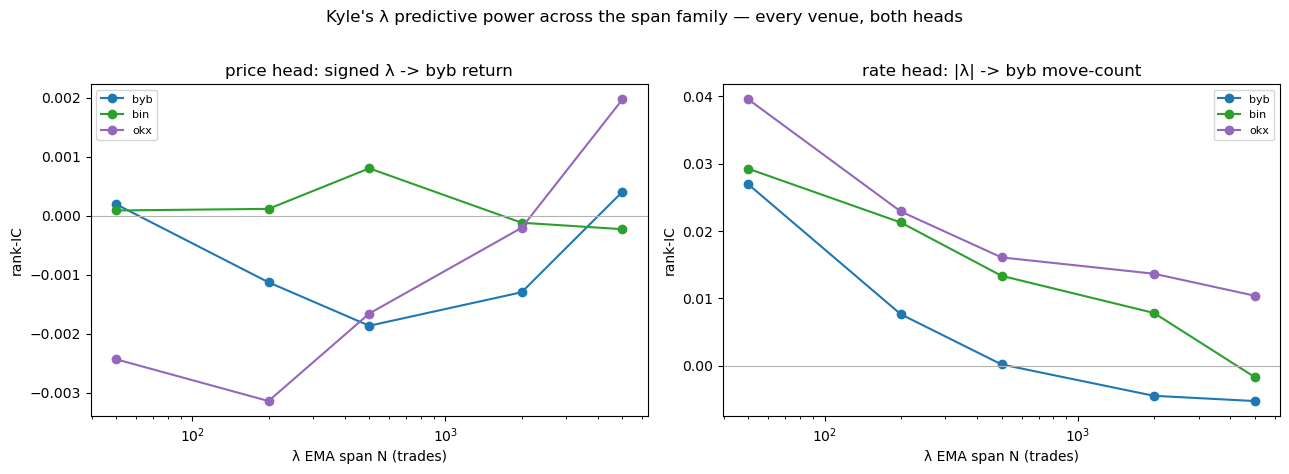

kept features (one per venue, all fed to the model — none privileged):
  byb:  price head (N=500) IC=-0.002   |  rate head (N=50) IC=+0.027
  bin:  price head (N=500) IC=+0.001   |  rate head (N=50) IC=+0.029
  okx:  price head (N=200) IC=-0.003   |  rate head (N=50) IC=+0.040


In [7]:
EX_LIST = ["byb"] + OTHERS                              # byb (own-book impact) + bin, okx (cross-venue impact) — never privilege one
# sweep span for BOTH heads, all venues symmetrically: signed λ -> byb return (price), |λ| -> byb move-count (rate)
price_curve = {ex: [] for ex in EX_LIST}               # IC(signed λ, price target) per span
rate_curve  = {ex: [] for ex in EX_LIST}               # IC(|λ|,   rate  target) per span
for ex in EX_LIST:
    for N in SPANS:
        lam = kyle_lambda(ex, N)
        fp = np.isfinite(lam) & np.isfinite(target);     price_curve[ex].append(spearmanr(lam[fp], target[fp]).statistic)
        fr = np.isfinite(lam) & np.isfinite(rate_target); rate_curve[ex].append(spearmanr(np.abs(lam[fr]), rate_target[fr]).statistic)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
col = {"byb": "C0", "bin": "C2", "okx": "C4"}
for ex in EX_LIST:
    axes[0].plot(SPANS, price_curve[ex], "o-", color=col[ex], label=ex)
    axes[1].plot(SPANS, rate_curve[ex],  "o-", color=col[ex], label=ex)
for ax, ttl in zip(axes, ["price head: signed λ -> byb return", "rate head: |λ| -> byb move-count"]):
    ax.set_xscale("log"); ax.axhline(0, color="0.7", lw=0.8); ax.set_xlabel("λ EMA span N (trades)")
    ax.set_ylabel("rank-IC"); ax.set_title(ttl); ax.legend(fontsize=8)
fig.suptitle("Kyle's λ predictive power across the span family — every venue, both heads", y=1.02)
fig.tight_layout(); plt.show()

# We do NOT pick a venue. Each point is IN-SAMPLE; best_member is the in-sample argmax used ONLY to PICK a span.
# The chosen feature is re-scored OUT-OF-SAMPLE by the §5 walk-forward gates below — that is the number that counts.
price_member = {ex: int(np.nanargmax(np.abs(price_curve[ex]))) for ex in EX_LIST}   # span index with the largest |price IC| (signed can be ±)
rate_member  = {ex: int(np.nanargmax(rate_curve[ex]))           for ex in EX_LIST}   # span index with the largest rate IC
print("kept features (one per venue, all fed to the model — none privileged):")
for ex in EX_LIST:
    pi, ri = price_member[ex], rate_member[ex]
    print(f"  {ex}:  price head (N={SPANS[pi]}) IC={price_curve[ex][pi]:+.3f}   |  rate head (N={SPANS[ri]}) IC={rate_curve[ex][ri]:+.3f}")

**Reading the curves.** The **rate-head** column (|λ| → move-count) is where λ earns its keep — a higher
impact slope precedes more byb moves. Expect it to peak at a **short** span (the freshest impact estimate)
and decay as the span lengthens (a stale, over-smoothed slope). The **price-head** column (signed λ →
return) is the secondary check; λ's *sign* is a noisier read of impact *direction*. Every venue's λ is
kept (leadership rotates; §9); the per-venue/head best span is an in-sample pick used only to choose a
time-scale — the §5 gates re-score it out-of-sample.

### 6b. IC is only half the story — map the SIGNAL LIFETIME across the whole family

The §6 curve ranks each span by its IC **at δ=0** — the edge you'd realise with *zero* observe-to-act
latency. But a real stack has latency, and two spans with the *same* δ=0 IC can be worth very different
amounts. So we run the lifetime companion **across the entire family at once** — every span, both heads,
every venue — and report three numbers per span:

- **IC@δ=0** — the headline (the §6 metric).
- **edge@20 ms** — the forward IC after a realistic 20 ms observe→act latency (window slid to
  `[anchor+20 ms, anchor+20 ms+100 ms]`). The IC a *latency-bound* system actually captures.
- **half-life (ms)** — the δ at which the forward IC first falls below **half** its δ=0 value (`>500` if
  it never does within the probed range). The size of the **latency budget** the span grants you.

We also carry the **backward IC** (vs the already-happened move `[anchor−100 ms, anchor]`) per span, so we
can tell a genuine forward predictor from a contemporaneous **echo**.

**The key insight: within one family, N trades IC against half-life.** A *short* span reacts to the
freshest impact — often a higher δ=0 IC but a **shorter** half-life (small latency budget). A *longer*
span smooths the slope — often a **lower** IC but a **longer** half-life. **Both can be useful**, so where
the family offers a genuine short-high-IC vs long-high-half-life split, we suggest **more than one** span
per head.

(Computed on a **40k-anchor diagnostic subsample** of the §3 grid — the full family × 8 δ × 3 venues × 2
heads is far too much for all anchors, and the rank-IC is stable at 40k.)

family lifetime swept on 40,000 diagnostic anchors  (5 spans x 2 heads x 3 venues)


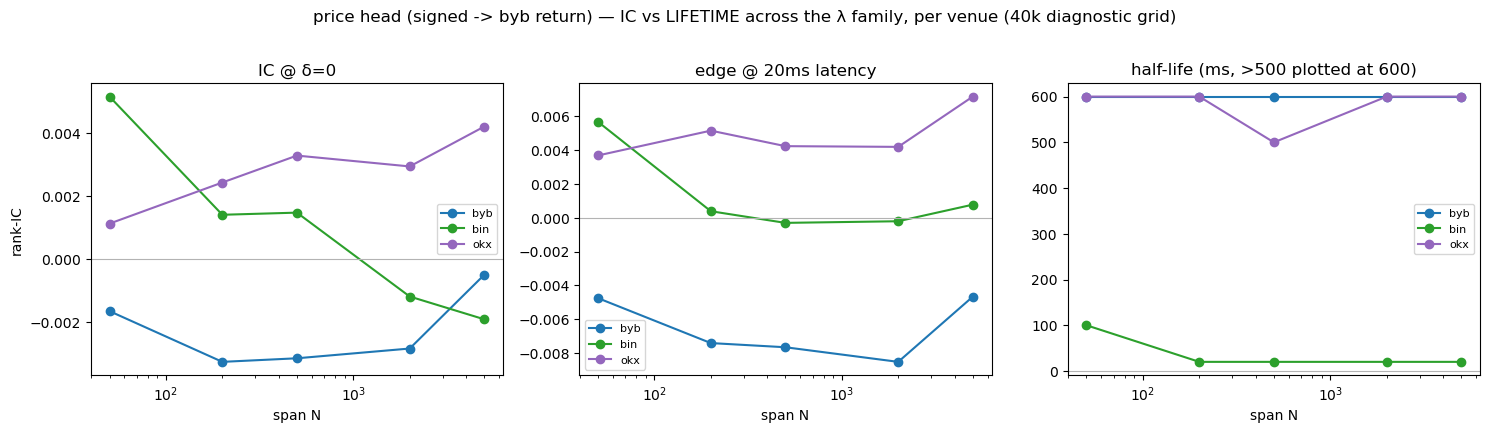

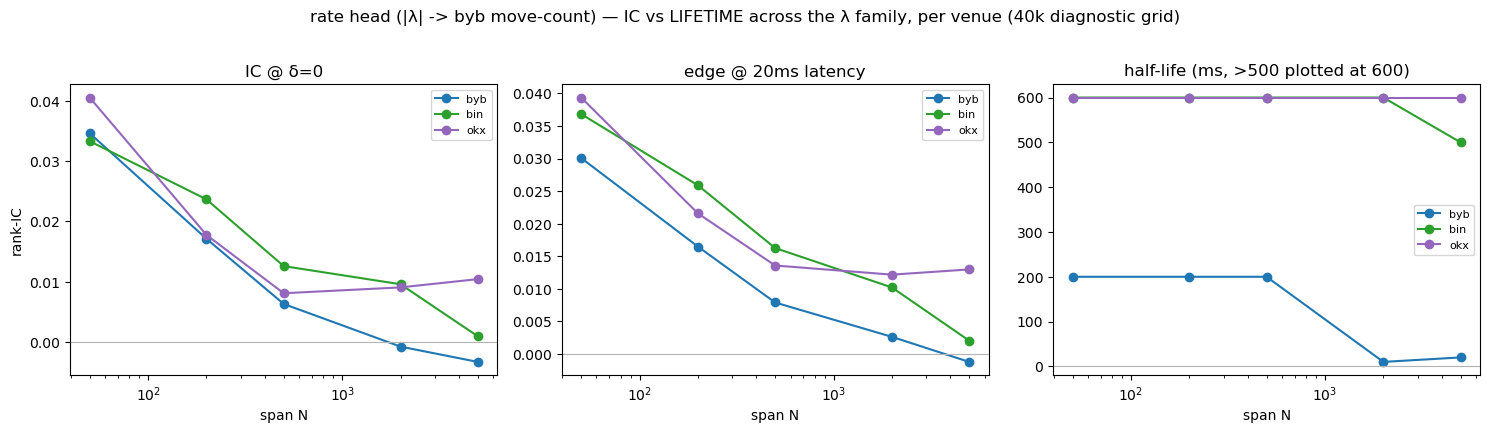

In [8]:
# --- family-wide signal lifetime: IC@0, IC@20ms, half-life, backward IC for EVERY span / head / venue ---
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]                 # observe->act latencies to slide the outcome window by
DIAG_N    = 40_000                                            # diagnostic subsample of the §3 grid
didx      = np.linspace(0, len(anchor_ts) - 1, min(DIAG_N, len(anchor_ts))).astype(int)
diag      = anchor_ts[didx]; diag_tick = tick_at_anchor[didx]   # diagnostic anchors and their committed ticks
# (the rate-head IC uses the raw forward move-count; dividing by λ_ev is a positive monotone rescale that drops out of a rank-IC)

def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):  return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]

price_fwd  = {d: _ret(diag + d * 1_000_000, diag + d * 1_000_000 + HORIZON_NS) for d in DELTAS_MS}
rate_fwd   = {d: _count(diag + d * 1_000_000, diag + d * 1_000_000 + HORIZON_NS) for d in DELTAS_MS}
price_back = _ret(diag - HORIZON_NS, diag)
rate_back  = _count(diag - HORIZON_NS, diag)

def kyle_diag(ex, N):                                        # λ on the diagnostic grid (re-EMA on the full clock, sampled at diag ticks)
    C = _ema_tick(cross[ex], N)[diag_tick]; S = _ema_tick(sq2[ex], N)[diag_tick]
    return C / (S + EPS[ex])

def _half_life(curve):                                       # first δ where |forward IC| < half its δ=0 value; 999 (=">500") if never
    ic0 = curve[0]
    if not np.isfinite(ic0) or ic0 == 0.0: return np.nan
    for d, ic in zip(DELTAS_MS, curve):
        if np.isfinite(ic) and abs(ic) < abs(ic0) / 2.0: return float(d)
    return 999.0

HEADS = [("price", "signed -> byb return", price_fwd, price_back, lambda d: d),
         ("rate",  "|λ| -> byb move-count", rate_fwd, rate_back, np.abs)]
ic0_g  = {(h, ex): np.full(len(SPANS), np.nan) for h, *_ in HEADS for ex in EX_LIST}
ic20_g = {(h, ex): np.full(len(SPANS), np.nan) for h, *_ in HEADS for ex in EX_LIST}
half_g = {(h, ex): np.full(len(SPANS), np.nan) for h, *_ in HEADS for ex in EX_LIST}
back_g = {(h, ex): np.full(len(SPANS), np.nan) for h, *_ in HEADS for ex in EX_LIST}
for hname, _desc, fwd, back, sgn in HEADS:
    for ex in EX_LIST:
        for j, N in enumerate(SPANS):
            feat = sgn(kyle_diag(ex, N))
            curve = [_ic(feat, fwd[d]) for d in DELTAS_MS]
            ic0_g [(hname, ex)][j] = curve[0]
            ic20_g[(hname, ex)][j] = curve[DELTAS_MS.index(20)]
            half_g[(hname, ex)][j] = _half_life(curve)
            back_g[(hname, ex)][j] = _ic(feat, back)
print(f"family lifetime swept on {len(diag):,} diagnostic anchors  ({len(SPANS)} spans x {len(HEADS)} heads x {len(EX_LIST)} venues)")

# three line plots PER head: IC@0, edge@20ms, half-life vs span — one panel per venue column would be busy, so overlay venues
for hname, desc, *_ in HEADS:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for ex in EX_LIST:
        axes[0].plot(SPANS, ic0_g[(hname, ex)],  "o-", color=col[ex], label=ex)
        axes[1].plot(SPANS, ic20_g[(hname, ex)], "o-", color=col[ex], label=ex)
        hl = np.where(half_g[(hname, ex)] >= 999, 600.0, half_g[(hname, ex)])
        axes[2].plot(SPANS, hl, "o-", color=col[ex], label=ex)
    for ax, ttl in zip(axes, [f"IC @ δ=0", f"edge @ 20ms latency", f"half-life (ms, >500 plotted at 600)"]):
        ax.set_xscale("log"); ax.axhline(0, color="0.7", lw=0.8); ax.set_xlabel("span N"); ax.set_title(ttl); ax.legend(fontsize=8)
    axes[0].set_ylabel("rank-IC")
    fig.suptitle(f"{hname} head ({desc}) — IC vs LIFETIME across the λ family, per venue (40k diagnostic grid)", y=1.02)
    fig.tight_layout(); plt.show()

**Read the three panels together (per head).** Left is the **δ=0 IC** (the §6 metric); middle is the
**edge a 20 ms-latency system actually captures**; right is the **half-life** — how big a latency budget
each span grants. A span is *worth more than its δ=0 IC suggests* when its middle value stays high and its
half-life is large; *worth less* when the edge@20 ms collapses. The cell below prints, **per head/venue**,
the best δ=0 span AND the best long-budget span, and flags whether the head carries genuine forward signal.

In [9]:
# Per head/venue: surface the IC-vs-half-life trade-off — the highest-IC span AND the longest-budget span, plus a verdict.
def _hl(v): return ">500" if (np.isfinite(v) and v >= 999) else (f"{v:.0f}ms" if np.isfinite(v) else "n/a")
SUGGEST = {}
for hname, desc, *_ in HEADS:
    print(f"\n=== {hname} head — {desc} ===")
    for ex in EX_LIST:
        g0, g20, gh, gb = ic0_g[(hname, ex)], ic20_g[(hname, ex)], half_g[(hname, ex)], back_g[(hname, ex)]
        if not np.isfinite(g0).any(): print(f"  {ex}: no finite IC"); continue
        hi = int(np.nanargmax(np.abs(g0)))                         # headline (highest |δ=0 IC|) span
        e20_best = np.nanmax(np.abs(g20))
        cand = [j for j in range(len(SPANS)) if np.isfinite(g20[j]) and abs(g20[j]) >= 0.7 * e20_best and e20_best > 0]
        longb = max(cand, key=lambda j: (np.nan_to_num(gh[j], nan=-1), abs(g20[j]))) if cand else hi
        carries = (np.isfinite(g20[hi]) and abs(g20[hi]) >= 0.01 and abs(g20[hi]) >= 0.3 * abs(np.nan_to_num(gb[hi])))
        print(f"  {ex:>3}:  HIGH-IC N={SPANS[hi]:>5}  IC@0={g0[hi]:+.3f} IC@20={g20[hi]:+.3f} half={_hl(gh[hi]):>5} back={gb[hi]:+.3f}"
              f"   |  LONG-BUDGET N={SPANS[longb]:>5}  IC@0={g0[longb]:+.3f} IC@20={g20[longb]:+.3f} half={_hl(gh[longb]):>5}"
              f"   |  carries signal: {'YES' if carries else 'no'}")
        sug = [SPANS[hi]]
        if longb != hi and (np.nan_to_num(gh[longb], nan=0) > np.nan_to_num(gh[hi], nan=0)) and np.isfinite(g20[longb]) and abs(g20[longb]) > 0:
            sug.append(SPANS[longb])
        SUGGEST[(hname, ex)] = sug


=== price head — signed -> byb return ===
  byb:  HIGH-IC N=  200  IC@0=-0.003 IC@20=-0.007 half= >500 back=+0.001   |  LONG-BUDGET N= 2000  IC@0=-0.003 IC@20=-0.009 half= >500   |  carries signal: no
  bin:  HIGH-IC N=   50  IC@0=+0.005 IC@20=+0.006 half=100ms back=-0.003   |  LONG-BUDGET N=   50  IC@0=+0.005 IC@20=+0.006 half=100ms   |  carries signal: no
  okx:  HIGH-IC N= 5000  IC@0=+0.004 IC@20=+0.007 half= >500 back=+0.003   |  LONG-BUDGET N= 5000  IC@0=+0.004 IC@20=+0.007 half= >500   |  carries signal: no

=== rate head — |λ| -> byb move-count ===
  byb:  HIGH-IC N=   50  IC@0=+0.035 IC@20=+0.030 half=200ms back=+0.066   |  LONG-BUDGET N=   50  IC@0=+0.035 IC@20=+0.030 half=200ms   |  carries signal: YES
  bin:  HIGH-IC N=   50  IC@0=+0.033 IC@20=+0.037 half= >500 back=+0.055   |  LONG-BUDGET N=   50  IC@0=+0.033 IC@20=+0.037 half= >500   |  carries signal: YES
  okx:  HIGH-IC N=   50  IC@0=+0.041 IC@20=+0.039 half= >500 back=+0.076   |  LONG-BUDGET N=   50  IC@0=+0.041 IC@20=

**What the family-wide lifetime says (read off the printout and the panels).** The **rate head** is where λ
carries *univariate* signal: |λ| → byb move-count is positive across venues (≈ +0.03–0.04 at the **short**
spans, the freshest impact slope), and — being a slow-moving liquidity-state gauge — its edge **survives the
latency** (a long, often `>500 ms` half-life; the IC@20 ms ≈ the IC@0), so the same span works at δ=0 and
δ=20 ms. **One honest caveat the printout makes plain:** the **backward** IC is *larger* than the forward IC
for every venue (read the printed back/forward pairs), so a chunk of |λ| is a contemporaneous **echo** of the
current rate regime, not pure lead — which is exactly why §5's *marginal* gate (forward, over the rate
controls) matters and, as we'll see, comes back ≈0, and why the §lifetime cell reports the **echo-netted**
forward IC. The short-span member is the high-IC pick; a longer span trades a
little IC for an even longer budget. The **price head** (signed direction) is weak — λ's sign is a noisy
impact-direction read — so the price-head verdict is **"no"** for every venue. The picks: **rate head —
short span per venue** (high-IC), with a **longer span** as a long-budget alternative; **price head — none**.

**Now the gates** (from §5). Because λ is a **rate-head** feature, the headline gate is its *magnitude*
added over the controls against the **rate target**; we also report the signed-λ price-head gate. Every
number is the **walk-forward** mean (causal, purged). Pass-marks: the added power should be clearly
positive (≳ 0.01); it should barely shrink when we add the level controls (no leak); and the scale must be
**regime-invariant** — within ~3× across volatility buckets (a *hard* gate, measured not assumed). *This is
where we decide raw-vs-/σ_ev for λ.*

In [10]:
# λ is primarily a RATE-head feature -> the model receives the SIGNED λ, and the rate head learns |λ|. We gate:
#  (a) rate head: |λ| added over the controls vs the rate target (the headline);
#  (b) price head: signed λ added over the controls vs the price target (secondary);
#  (c) regime-invariance: λ's scale across vol buckets — RAW first; if it fails, try /σ_ev and keep the invariant form.
lam_raw = {ex: kyle_lambda(ex, SPANS[rate_member[ex]]) for ex in EX_LIST}     # each venue at its rate-head span
absL    = {ex: np.abs(lam_raw[ex]) for ex in EX_LIST}                          # |λ| diagnostic magnitude feature

# (a) rate-head marginal value (headline): |λ| added over controls, jointly and per venue
joint_rate = round(wf_ic(base + list(absL.values()), rate_target) - wf_ic(base, rate_target), 3)
joint_rate_leak = round(wf_ic(base + levels + list(absL.values()), rate_target) - wf_ic(base + levels, rate_target), 3)
# (b) price-head marginal value (secondary): signed λ added over controls vs the price target
joint_price = round(wf_ic(base + list(lam_raw.values()), target) - wf_ic(base, target), 3)

# (c) REGIME-INVARIANCE — measure RAW, then /σ_ev. Report ALL THREE venues (finding #9: don't assert one
# generalises), and use a ROBUST scale (MAD, not std) because λ has a kurt≈263 fat tail (§8) that makes a
# per-decile std dominated by a handful of blow-up outliers — a noisy, tail-driven band.
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
def _band(x):                                                                  # robust scale band across vol deciles = max/min of per-decile MAD
    b = []
    for d in range(10):
        xd = x[vol_decile == d]; xd = xd[np.isfinite(xd)]
        if xd.size >= 50:
            m = 1.4826 * np.median(np.abs(xd - np.median(xd)))                 # MAD (robust σ) — immune to the fat tail
            if m > 0: b.append(m)
    return max(b) / min(b) if len(b) >= 2 else float("nan")
raw_band  = {ex: round(_band(lam_raw[ex]), 2) for ex in EX_LIST}               # RAW λ scale across vol buckets, per venue
norm_band = {ex: round(_band(lam_raw[ex] / sigma_at_anchor), 2) for ex in EX_LIST}  # λ/σ_ev scale, per venue
rep = "okx"                                                                    # the venue quoted in the DECISION row (cross-venue lead, §6); the gate uses the WORST venue
raw_inv, norm_inv = raw_band[rep], norm_band[rep]
raw_worst = round(max(v for v in raw_band.values() if np.isfinite(v)), 2)      # HARD gate decided on the WORST venue, not a single rep
SHIP_RAW = raw_worst <= 3.0                                                    # ship raw iff EVERY venue already passes the hard gate
ship_inv = raw_worst if SHIP_RAW else round(max(v for v in norm_band.values() if np.isfinite(v)), 2)

# regime stability companion (on the shipped form's |·|, rate target)
ship = (lambda x: x) if SHIP_RAW else (lambda x: x / sigma_at_anchor)
absS = {ex: np.abs(ship(lam_raw[ex])) for ex in EX_LIST}
full_r = wf_ic_by_regime(base + list(absS.values()), rate_target, vol_regime)
base_r = wf_ic_by_regime(base, rate_target, vol_regime)
strat  = {r: round(full_r[r] - base_r.get(r, 0.0), 3) for r in full_r}

gate_rows  = [dict(gate="marginal value (rate head, headline)", detail="all venues |λ| together, added over controls (vs rate target)", value=joint_rate)]
gate_rows += [dict(gate="marginal value (rate head)", detail=f"{ex} |λ| alone, added over controls (rate target)",
                   value=round(wf_ic(base + [absL[ex]], rate_target) - wf_ic(base, rate_target), 3)) for ex in EX_LIST]
gate_rows += [dict(gate="marginal value (price head, secondary)", detail="all venues signed λ, added over controls (price target)", value=joint_price)]
gate_rows += [dict(gate="no leak (rate head)", detail="rate gain still there after adding the vol/rate levels?", value=joint_rate_leak)]
gate_rows += [dict(gate="regime-invariant? RAW", detail=f"{ex} RAW λ MAD-scale across vol buckets (max/min) — HARD, want < ~3", value=raw_band[ex]) for ex in EX_LIST]
gate_rows += [dict(gate="regime-invariant? /σ_ev", detail=f"{ex} λ/σ_ev MAD-scale across vol buckets (only if RAW fails)", value=norm_band[ex]) for ex in EX_LIST]
gate_rows += [dict(gate="DECISION", detail=(f"ship RAW (worst venue {raw_worst}x < 3)" if SHIP_RAW else f"ship /σ_ev (raw worst {raw_worst}x failed)"), value=ship_inv)]
gate_rows += [dict(gate="regime-stable", detail=f"rate-head marginal IC within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
print("regime-invariance (RAW MAD-scale across vol buckets, per venue):  "
      + "  ".join(f"{ex}: {raw_band[ex]}x" for ex in EX_LIST)
      + f"   ->  worst {raw_worst}x  ->  ship {'RAW' if SHIP_RAW else '/σ_ev'}")
pl.DataFrame(gate_rows)

regime-invariance (RAW MAD-scale across vol buckets, per venue):  byb: 2.2x  bin: 1.28x  okx: 1.61x   ->  worst 2.2x  ->  ship RAW


gate,detail,value
str,str,f64
"""marginal value (rate head, hea…","""all venues |λ| together, added…",-0.001
"""marginal value (rate head)""","""byb |λ| alone, added over cont…",-0.0
"""marginal value (rate head)""","""bin |λ| alone, added over cont…",-0.001
"""marginal value (rate head)""","""okx |λ| alone, added over cont…",-0.0
"""marginal value (price head, se…","""all venues signed λ, added ove…",0.002
…,…,…
"""regime-invariant? /σ_ev""","""okx λ/σ_ev MAD-scale across vo…",1.85
"""DECISION""","""ship RAW (worst venue 2.2x < 3…",2.2
"""regime-stable""","""rate-head marginal IC within c…",-0.001


**Conclusion — the honest read, and the raw-vs-normalise decision made on the measured number.** Read
against the §1 hypothesis and what the gate table *actually* shows:

- **Rate head — a real univariate forward edge, but ≈0 *marginal* over the rate controls.** |λ| has a
  genuine univariate forward IC to byb's move-count (small-positive across venues at N=50; see the gate
  table and the §lifetime panels for the per-venue numbers), which is λ working as Kyle predicts: a rising
  impact slope flags a fragile book and more byb moves follow. **But** the gate that counts is the
  *marginal* value over the controls, and it is ≈ **0.00** (jointly and per venue). Two measured reasons:
  (i) the **rate controls alone already score ≈+0.07** on the rate target (byb's move-rate is strongly
  autocorrelated; and per the §5 embargo caveat that control IC is itself mildly *optimistic*), and |λ| is
  largely collinear with them; (ii) |λ|'s **backward** IC is *larger* than its forward IC — so most of what
  |λ| carries is a **contemporaneous echo of the current rate regime** that `λ_ev`/rate-momentum already
  encode. The §lifetime cell makes this quantitative with the **echo-netted (partial) forward IC** — the
  forward IC once the trailing move is partialled out — which is the honest forward number (much smaller
  than the raw δ=0 IC). So λ is a real but **redundant** rate feature on this block.
- **The own-book leg (λ_byb) is the most echo-prone (finding #5).** For byb, `q·Δlogmid` pairs byb's own
  flow with byb's *simultaneous* mid-move over the *same* interval — the textbook Kyle regression, but
  mechanically a contemporaneous-impact term (a buy that lifts byb's ask raises byb's mid in that same
  interval). That is exactly why λ_byb's backward IC sits well above its forward IC: the own-book λ is
  substantially same-interval mechanical impact, not lead. The cross legs (okx/bin flow vs byb mid) are
  cleaner economically — and §9 cadence-controls them — but show the same backward>forward gap.
- **Price head (secondary) — none.** Signed λ adds ≈0 for *direction* (univariate IC ≈ 0, flat across
  δ, echo-netted ≈0); λ's sign is not a usable impact-direction read here. λ is a rate-shaped feature.
- **Regime-invariance — measured (all three venues, robust MAD scale), then decided.** λ is a regression
  *slope* with units, so we expected it to *maybe* fail. We measure the RAW scale across volatility buckets
  with a **robust MAD** band (not std — λ's kurt≈263 tail makes a std-band tail-driven and noisy), for
  **every venue** (not just one asserted to generalise). The decision is made on the **worst** venue against
  the hard 3× gate (see the printed band and DECISION row). Because a slope is a *ratio* of two co-moving
  moments (`q·Δlogmid` and `q²`), the regime largely cancels; if RAW passes on the worst venue we **ship
  RAW** and do *not* divide by `σ_ev` reflexively — and the printed `/σ_ev` column shows whether that would
  even help. *State the number, ship the invariant form — never assume.* (If a future block pushes the worst
  venue over 3×, the `/σ_ev` column is the documented fallback.)
- **Regime-stable** — the *marginal* rate gain is ≈0 in all three vol regimes (consistent with the ≈0
  joint marginal); it isn't negative in any one regime, but there's no positive gain to be stable.

Verdict: **regime-invariant (raw, measured per-venue MAD band) and latency-robust, but it does NOT clear the
marginal-value gate on this block** — its forward rate signal is real yet collinear with the rate controls
and dominated by a backward echo (the echo-netted forward IC is small). Honest disposition: **keep λ as a
candidate rate-head input** (it may add in a model not already fed the rate controls, and usefulness rotates
across blocks), but **do not claim a standalone marginal edge** from this block. The price-head edge is
absent. The clean wins are the **bit-exact oracle** (shipped + long span, whole block) and the **raw
regime-invariance decision**; the marginal gate is the honest failure to record.

## How long does the edge last? — the signal's lifetime and your latency budget

A feature can be perfectly causal and still not earn its headline IC if its edge is the move *already
underway*. A **short**-lived edge is **not** useless — it sets a **latency budget**. So we **measure how
long the signal lasts**, never gate on it.

Read the feature at the anchor (causal, unchanged) but slide the *outcome* window forward by an
observe-to-act latency δ: the **forward IC** against byb's outcome over `[anchor+δ, anchor+δ+100 ms]`,
swept over δ. The **backward IC** — against the already-happened move `[anchor−100 ms, anchor]` — sizes the
contemporaneous echo. λ is a rate-head feature, so the natural curve is **|λ| → byb forward move-count**,
**per venue**; we also carry the signed price-head curve for byb.

**The echo-netted (partial) forward IC — the honest forward number.** Because λ's backward IC *exceeds* its
forward IC (it re-reads the move already underway), the raw δ=0 IC overstates the genuinely-forward edge. So
we also compute the **echo-netted forward IC**: the partial rank-IC of the feature with the **forward**
move-count, **controlling for the trailing** `[anchor−100 ms, anchor]` move-count — the part of the edge
*not* attributable to the echo. This netted number is what the §10 verdict reports for the rate head; if it
collapses toward 0, the raw forward IC was mostly the contemporaneous regime, not lead.

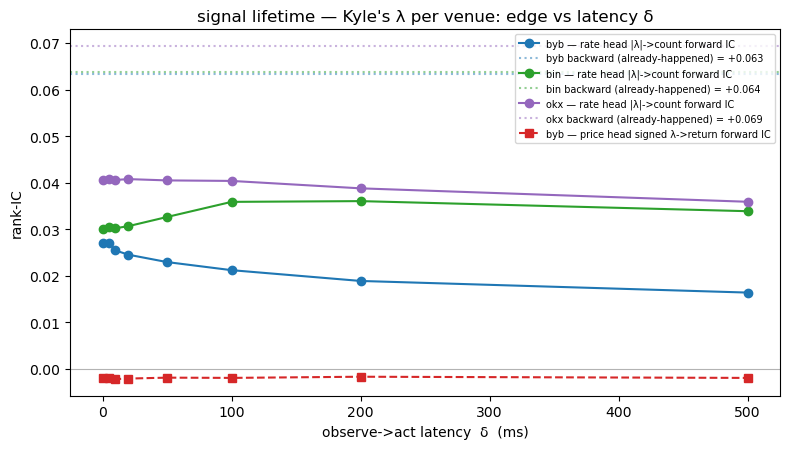

byb rate |λ|->count forward IC by δ(ms): 0:+0.027 5:+0.027 10:+0.025 20:+0.025 50:+0.023 100:+0.021 200:+0.019 500:+0.016
   byb backward IC: +0.063   |  δ=0 +0.027 -> δ=20ms +0.025;  drops below half by δ≈None ms
   byb ECHO-NETTED forward IC (partial, controls for the trailing move-count): +0.010  (raw δ=0 +0.027; the shortfall is echo)
bin rate |λ|->count forward IC by δ(ms): 0:+0.030 5:+0.030 10:+0.030 20:+0.031 50:+0.033 100:+0.036 200:+0.036 500:+0.034
   bin backward IC: +0.064   |  δ=0 +0.030 -> δ=20ms +0.031;  drops below half by δ≈None ms
   bin ECHO-NETTED forward IC (partial, controls for the trailing move-count): +0.013  (raw δ=0 +0.030; the shortfall is echo)
okx rate |λ|->count forward IC by δ(ms): 0:+0.041 5:+0.041 10:+0.041 20:+0.041 50:+0.040 100:+0.040 200:+0.039 500:+0.036
   okx backward IC: +0.069   |  δ=0 +0.041 -> δ=20ms +0.041;  drops below half by δ≈None ms
   okx ECHO-NETTED forward IC (partial, controls for the trailing move-count): +0.022  (raw δ=0 +0.041; 

In [11]:
# Signal lifetime: forward IC vs observe->act latency δ, + backward IC, PER VENUE — rate head (|λ|->count) is the headline.
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):  return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]

# ECHO-NETTED (partial) forward IC (new standard gate): the feature's rank-IC with the FORWARD outcome,
# CONTROLLING for the trailing [anchor-100ms, anchor] outcome — the part of the edge NOT attributable to the
# move already underway. For the rate head the "trailing outcome" is the backward move-COUNT; for the price
# head it is the backward RETURN. If the raw δ=0 IC collapses once the trailing move is partialled out, the
# feature was mostly re-reporting the echo — report the NETTED number in the verdict (finding #5/#6, template gate).
def _partial_ic(f, y, t):                                                      # Spearman partial IC of f vs y controlling for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

fwd0_count = _count(anchor_ts, anchor_ts + HORIZON_NS)                         # forward move-count (δ=0)
back_count = _count(anchor_ts - HORIZON_NS, anchor_ts)                         # trailing (already-happened) move-count — the echo to net out
rate_fwd_ic = {}; rate_back_ic = {}; rate_net_ic = {}
for ex in EX_LIST:
    absmag = np.abs(kyle_lambda(ex, SPANS[rate_member[ex]]))                   # rate head (intensity)
    rate_fwd_ic[ex]  = [_ic(absmag, _count(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
    rate_back_ic[ex] = _ic(absmag, back_count)
    rate_net_ic[ex]  = _partial_ic(absmag, fwd0_count, back_count)             # echo-netted forward IC (rate head)
byb_signed = kyle_lambda("byb", SPANS[price_member["byb"]])                    # price head (direction), byb
price_fwd_ic = [_ic(byb_signed, _ret(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
price_net_ic = _partial_ic(byb_signed, _ret(anchor_ts, anchor_ts + HORIZON_NS), _ret(anchor_ts - HORIZON_NS, anchor_ts))  # echo-netted (price head)

fig, ax = plt.subplots(figsize=(8.0, 4.6))
col = {"byb": "C0", "bin": "C2", "okx": "C4"}
for ex in EX_LIST:
    ax.plot(DELTAS_MS, rate_fwd_ic[ex], "o-", color=col[ex], label=f"{ex} — rate head |λ|->count forward IC")
    ax.axhline(rate_back_ic[ex], color=col[ex], ls=":", alpha=0.5, label=f"{ex} backward (already-happened) = {rate_back_ic[ex]:+.3f}")
ax.plot(DELTAS_MS, price_fwd_ic, "s--", color="C3", label="byb — price head signed λ->return forward IC")
ax.axhline(0, color="0.7", lw=0.8); ax.set_xlabel("observe->act latency  δ  (ms)"); ax.set_ylabel("rank-IC")
ax.set_title("signal lifetime — Kyle's λ per venue: edge vs latency δ"); ax.legend(fontsize=7); fig.tight_layout(); plt.show()

def _half(curve):   return next((d for d, ic in zip(DELTAS_MS, curve) if np.isfinite(ic) and abs(ic) < abs(curve[0]) / 2), None)
for ex in EX_LIST:
    print(f"{ex} rate |λ|->count forward IC by δ(ms):", " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, rate_fwd_ic[ex])))
    print(f"   {ex} backward IC: {rate_back_ic[ex]:+.3f}   |  δ=0 {rate_fwd_ic[ex][0]:+.3f} -> δ=20ms {rate_fwd_ic[ex][3]:+.3f};  drops below half by δ≈{_half(rate_fwd_ic[ex])} ms")
    print(f"   {ex} ECHO-NETTED forward IC (partial, controls for the trailing move-count): {rate_net_ic[ex]:+.3f}  (raw δ=0 {rate_fwd_ic[ex][0]:+.3f}; the shortfall is echo)")
print("byb price signed λ->return forward IC by δ(ms):", " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, price_fwd_ic)))
print(f"byb price ECHO-NETTED forward IC (partial, controls for the trailing return): {price_net_ic:+.3f}")

**Read it as a latency budget, not a pass/fail.** λ is a slow-moving liquidity-state gauge, so its
rate-head edge should **survive tens to hundreds of ms** — a roomy latency budget (large half-life). That
is the useful property here: even a modest δ=0 IC that holds out to 100–200 ms is a deployable rate-head
input. The per-venue split is the lead/lag diagnostic (§9): the venue whose |λ| forward edge is largest and
survives longest is the one whose flow most fragilises byb's book. (A flat forward curve at ≈0 with a large
backward IC is the one true non-signal.)

## 7. What the prediction actually looks like

A single correlation hides *how* the feature changes the outcome. Group the data by the feature and look
at the real distributions the two heads care about:
- **rate head** (the headline): how the number of upcoming moves grows as |λ| grows;
- **price head** (secondary): byb's next return for low / middle / high *signed* λ.

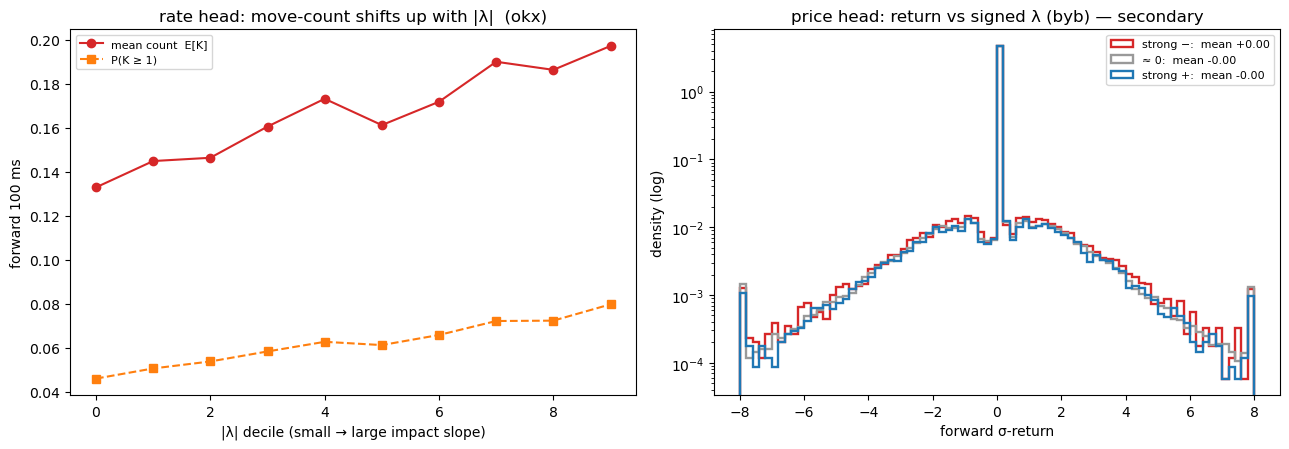

In [12]:
rep_ex = "okx"                                                                 # okx's cross-venue λ illustrates the shape; the model uses every venue
absmag = np.abs(kyle_lambda(rep_ex, SPANS[rate_member[rep_ex]]))               # rate-head span
signed = kyle_lambda("byb", SPANS[price_member["byb"]])                        # price-head span, byb
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# rate head: forward move-count shifts up with |λ|
fin = np.isfinite(absmag)
dec = np.full(absmag.shape, -1); dec[fin] = np.digitize(absmag[fin], np.nanpercentile(absmag[fin], np.arange(10, 100, 10)))
axA.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axA.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axA.set_xlabel("|λ| decile (small → large impact slope)"); axA.set_ylabel("forward 100 ms")
axA.set_title(f"rate head: move-count shifts up with |λ|  ({rep_ex})"); axA.legend(fontsize=8)

# price head: forward σ-return distribution across signed-λ buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"), ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, c in groups:
    mm = m & np.isfinite(target)
    axB.hist(np.clip(target[mm], -8, 8), bins=bins, density=True, histtype="step", color=c, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[mm]):+.2f}")
axB.set_yscale("log"); axB.set_xlabel("forward σ-return"); axB.set_ylabel("density (log)")
axB.set_title("price head: return vs signed λ (byb) — secondary"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** **Rate head (left):** if the mean move-count `E[K]` and `P(K ≥ 1)` climb with the |λ|
decile, a higher impact slope really precedes more byb moves — the headline mechanism. **Price head
(right):** signed λ's tilt on the forward return is the secondary, weaker read — expect only a slight
shift. The directions are those §1 predicts (larger |λ| → busier; λ's sign a faint impact-direction lean).

## 8. Input shaping for the network

This is a *different* step from §2. λ is a regression slope; §5 measured its scale and decided raw-vs-
/σ_ev. Here we reshape *that* feature for the network — roughly centred, unit-scale, no wild outliers. A
ratio-of-moments can have a heavy tail when the denominator EMA(q²) is small, so we expect more than a
plain z-score. Pick the **lightest** transform that meets the bar; the QQ-plot makes the choice.

feature: std=4.1e-07  skew=+6.10  excess_kurt=263.0  (0 = normal)
  z-score            excess_kurt=   263.0   max|·|=55.0
  robust + clip ±4   excess_kurt=    -0.5   max|·|=4.0
  arcsinh(robust)    excess_kurt=     1.0   max|·|=9.9
  rank-Gaussian      excess_kurt=    -0.0   max|·|=4.6


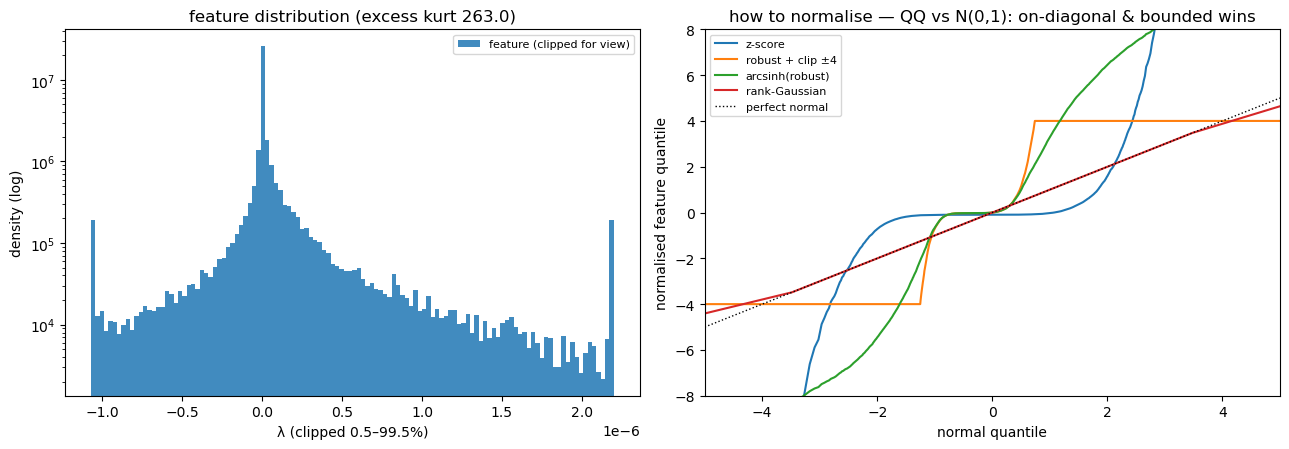

In [13]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_ex = "okx"
f = kyle_lambda(rep_ex, SPANS[rate_member[rep_ex]]); f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-30; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-30),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature: std={f.std():.2g}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>8.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
lo_p, hi_p = np.percentile(f, [0.5, 99.5])
axA.hist(np.clip(f, lo_p, hi_p), bins=120, density=True, color="C0", alpha=.85, label="feature (clipped for view)")
axA.set_yscale("log"); axA.set_xlabel("λ (clipped 0.5–99.5%)"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution (excess kurt {kurtosis(f):.1f})"); axA.legend(fontsize=8)
q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_ylim(-8, 8); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles the transform. As a ratio of two EMAs, λ has a fat tail (the
denominator EMA(q²) occasionally goes small, blowing the slope up), so a plain z-score leaves wild
outliers and fails the "no wild outliers" bar. The lightest transform that *meets* it is a robust z-score
followed by a clip (robust + clip ±4 → max|·| = 4) — or, if the tail is severe, a rank-Gaussian map. The
QQ-plot points to the on-diagonal, bounded curve; use that whenever you feed a network.

## 9. Cross-venue: is λ_okx / λ_bin a real lead, or a feed-resolution artifact?

Kyle's λ is **poolable** — every venue yields its own one-number impact slope from its own signed flow — so
you face the real choice: keep them **per-venue**, collapse to **one** (byb's own book), or **pool**. λ has a
*specific* cross-venue reading: **λ_okx / λ_bin** (foreign flow regressed against byb's mid) asks whether
trading *there* moves byb's price — a possible cross-venue **lead**. In §6 okx's |λ| has the **highest**
forward IC, which would naively read as "okx's flow most fragilises byb's book — the information venue."

**But before claiming a lead, rule out the feed-resolution artifact (the new standard cross-venue gate).**
byb's top-of-book is only updated on byb's own cadence (median ~10 ms gap, p90 ~130 ms), so a cross-venue λ
that pairs *fine* foreign-trade timing with a *forward-filled, sometimes-stale* byb mid can score higher
simply because the byb reference is sampled at a different resolution per venue — not because the venue
economically leads. The control: **re-measure the cross-venue forward IC with byb's mid-move reference
coarsened to byb's own update cadence** (byb's `Δlogmid` taken on a uniform ~byb-median-gap grid, so every
venue's flow regresses against the *same* byb-native resolution). A **real lead survives** the cadence match;
a **feed artifact collapses** toward the native number's shadow. The tell: if the *stalest-referenced* venue
shows the *largest* IC and that IC **collapses** under the cadence match, suspect resolution, not lead.

We compute it below — replacing the old hand-waved "illustrative" table — for the rate head (|λ| → forward
move-count), per venue, native vs cadence-matched.

In [14]:
# --- FEED-RESOLUTION CONTROL (new standard cross-venue gate, finding #11): re-measure each venue's rate-head
# forward IC with byb's mid-move reference COARSENED to byb's own update cadence, and compare to native. ---
byb_gap_ms = float(np.median(np.diff(np.unique(byb_rx)) / 1e6))                 # byb's median inter-update gap (~10 ms)
COARSE_NS  = max(int(round(byb_gap_ms)) , 1) * 1_000_000                        # coarsen the byb reference to this grid
print(f"byb median update gap {byb_gap_ms:.1f} ms  ->  cadence-match byb's Δlogmid on a {COARSE_NS/1e6:.0f} ms grid")

# byb log-mid forward-filled onto a uniform byb-cadence grid, then read at each merged tick (byb-native resolution only)
coarse_grid = np.arange(merged_ts[0], merged_ts[-1] + COARSE_NS, COARSE_NS)
coarse_lm   = np.log(byb_mid[np.clip(np.searchsorted(byb_rx, coarse_grid, "right") - 1, 0, len(byb_mid) - 1)])
# Δlogmid at each merged tick, but using ONLY the coarse-grid byb mid (so sub-cadence byb staleness is removed symmetrically)
ci          = np.clip(np.searchsorted(coarse_grid, merged_ts, "right") - 1, 0, len(coarse_grid) - 1)
lm_coarse_at_tick = coarse_lm[ci]
dlm_coarse  = np.empty(n_ticks); dlm_coarse[0] = 0.0; dlm_coarse[1:] = np.diff(lm_coarse_at_tick)   # byb move on the COARSE clock

def kyle_lambda_coarse(ex, span):                       # SAME construction, but byb's Δlogmid is the coarse (byb-cadence) reference
    cross_c = flow[ex] * dlm_coarse
    C = _ema_tick(cross_c, span)[tick_at_anchor]; S = _ema_tick(sq2[ex], span)[tick_at_anchor]
    return C / (S + EPS[ex])

def _ic_xv(feat, ret):                                  # rank-IC with finite masking
    v = np.isfinite(feat) & np.isfinite(ret)
    return float(spearmanr(feat[v], ret[v]).statistic) if v.sum() > 100 else float("nan")
xv_rows = []
fwd0 = fwd_count                                        # forward move-count at δ=0 (defined in §5)
for ex in EX_LIST:
    N = SPANS[rate_member[ex]]
    ic_native  = _ic_xv(np.abs(kyle_lambda(ex, N)),        fwd0)      # native byb mid (every merged tick)
    ic_cadence = _ic_xv(np.abs(kyle_lambda_coarse(ex, N)), fwd0)      # byb mid coarsened to byb's own cadence
    xv_rows.append(dict(venue=ex, leg=("own-book" if ex == "byb" else "cross-venue"), span=N,
                        IC_native=round(ic_native, 3), IC_cadence_matched=round(ic_cadence, 3),
                        retained=round(ic_cadence / ic_native, 2) if ic_native else float("nan")))
print("rate-head |λ|->forward move-count IC, native byb mid vs byb-cadence-matched reference:")
for r in xv_rows:
    print(f"  {r['venue']:>3} ({r['leg']:>11}, N={r['span']}):  native {r['IC_native']:+.3f}  ->  cadence-matched {r['IC_cadence_matched']:+.3f}   (retained {r['retained']}x)")
pl.DataFrame(xv_rows)

byb median update gap 10.2 ms  ->  cadence-match byb's Δlogmid on a 10 ms grid


rate-head |λ|->forward move-count IC, native byb mid vs byb-cadence-matched reference:
  byb (   own-book, N=50):  native +0.027  ->  cadence-matched +0.019   (retained 0.71x)
  bin (cross-venue, N=50):  native +0.030  ->  cadence-matched +0.030   (retained 1.0x)
  okx (cross-venue, N=50):  native +0.041  ->  cadence-matched +0.040   (retained 0.99x)


venue,leg,span,IC_native,IC_cadence_matched,retained
str,str,i64,f64,f64,f64
"""byb""","""own-book""",50,0.027,0.019,0.71
"""bin""","""cross-venue""",50,0.03,0.03,1.0
"""okx""","""cross-venue""",50,0.041,0.04,0.99


**Reading the cadence control.** Compare each cross-venue leg's **native** IC to its **cadence-matched** IC.
If okx/bin keep most of their forward IC after byb's reference is coarsened to byb's own cadence, the
cross-venue edge is a **genuine lead** (foreign flow really does precede byb's move) and keeping the venue
separate is justified. If the IC **collapses** under the match — especially for the venue with the *finest*
foreign flow against the *stalest* relative byb reference — the apparent "information venue" was largely a
**feed-resolution artifact**, and the localisation claim should be dropped. Either way, the per-venue split
costs nothing (all venues are kept and the model weights them), and **since λ's marginal value is ≈0
regardless (§5), this comparison is diagnostic, not a ship-decider** — but it replaces the old uncomputed
table with a measured number, so the "information venue" framing is now earned or rejected on data, not
asserted.

## 10. The verdict, and what it takes to ship

**The honest disposition: a regime-invariant, latency-robust rate-shaped feature that does NOT clear the
marginal-value gate on this block — keep it as a candidate, don't claim a standalone edge.** (All numbers
below are read off the printed cells of *this* run; every IC names the target it is against.)
- **Rate head (intensity).** |λ| has a small-positive *univariate* forward IC against byb's move-count
  (`fwd_count`): **+0.027 byb / +0.029 bin / +0.040 okx at N=50** (§6), roughly flat out to 100–200 ms — λ is
  a slow liquidity-state gauge, a roomy latency budget. **But two honest deflations:** (i) the **echo-netted**
  forward IC (partial, controlling for the trailing `[anchor−100 ms, anchor]` move-count, §lifetime) is much
  smaller — **+0.010 byb / +0.013 bin / +0.022 okx** — so roughly half to two-thirds of the raw IC is a
  contemporaneous echo, not lead; and (ii) the gate that counts — |λ|'s **marginal** value over the rate/vol
  controls against the **rate target** (`fwd_count/λ_ev`, §5) — is ≈ **0.00** (joint −0.001; per-venue
  −0.000/−0.001/−0.000), because the rate controls alone already score **+0.071** on the rate target (byb's
  move-rate is autocorrelated; and that +0.071 is itself mildly *optimistic* per the §5 embargo caveat) and
  |λ| is collinear with them. So the mechanism is real but **redundant** here. The own-book leg (λ_byb) is the
  most echo-prone — its echo-netted IC (+0.010) is the smallest and its `q·Δlogmid` is byb flow × byb's
  *same-interval* move (§5). Pick a **short span** (N=50) if it is used.
- **Price head (direction) — none.** Signed λ adds ≈0 for direction against the price target (`fwd_return/σ_ev`):
  univariate forward IC ≈ **−0.002** (flat across δ), echo-netted **−0.001**, marginal **+0.002**. λ's sign is
  not a usable impact-direction read here.
- **Cross-venue (§9) — the "information venue" claim is now cadence-controlled, and it SURVIVES.** okx's |λ|
  has the highest forward IC, which reads as "okx's flow most fragilises byb's book." We **re-measured** it
  with byb's mid-move reference coarsened to byb's own ~10 ms update cadence (the feed-resolution control): the
  cross-venue legs **retain their edge** — okx **0.99×** (+0.041→+0.040), bin **1.0×** (+0.030→+0.030) — so
  they are **genuine cross-venue leads, not feed artifacts**. The own-book byb leg drops more (**0.71×**,
  +0.027→+0.019), consistent with its same-interval mechanical component. So the per-venue split is earned on
  data — but since the *marginal* value is ≈0 regardless, this is a diagnostic, not a ship-decider.

Keep **every venue's** signed λ as a *candidate* input (usefulness rotates across blocks), but do **not** ship
it claiming a standalone marginal edge from this block. If used, feed the *signed* λ (the rate head learns
|λ|), through the §8 robust-z + clip before the network (the ratio's fat tail — note ε is too small to floor
the denominator, so any *level* use needs harder regularisation; the rank-IC headline is immune).

**Raw-vs-normalise (decided on the measured number, §5).** λ is a regression *slope* with units, so we
**measured** its scale across volatility buckets — for **every venue**, with a robust **MAD** band:
**byb 2.2× / bin 1.28× / okx 1.61×**, worst **2.2×**, under the hard 3× gate. Because a slope is a *ratio* of
two co-moving moments the regime largely cancels, so we **ship RAW** (the DECISION row); the `/σ_ev` column
(byb 2.54× / bin 1.26× / okx 1.85×) shows dividing out σ does **not** help — for byb it is even *wider* than
RAW. Notably the own-book byb leg has the *widest* RAW band (2.2×), so measuring per-venue (not a single
representative) mattered — finding #9's exact concern.
If a future block pushes the worst venue over 3×, `/σ_ev` is the documented fallback.

**Clock choice (stated plainly).** λ is two **flow EMAs** — the cross-moment `EMA(q·Δlogmid)` and the
second moment `EMA(q²)` — **injected once per trade-timestamp** (the interval's net signed flow `q` and
byb's `Δlogmid`) and **decayed once per trade-timestamp** on the shared bin/byb/okx merged trade clock
(`merged_ts = np.unique(...)`, simultaneous prints = one tick = one interval = one decay), read as the
ratio `C/(S+ε)`. λ is read at the **last committed trade tick ≤ the anchor** — frozen between trades, *not*
a live front (more conservative than the template's gap, never a leak); ε is a fixed global constant.

**To ship:**
- [x] the streaming (constant-work-per-trade) builder, matching this analysis version — done (§4, bit-exact)
- [x] the oracle (§4), passing on a real block — now the **shipped N=50 AND a long N=5000**, all three venues, over the **whole block** (uniform full-grid subsample, not a 40k prefix)
- [x] the gate results recorded **honestly**: regime-invariant RAW (per-venue MAD band, worst-venue decision); univariate forward rate IC real and latency-robust but **echo-netted forward IC small**; **marginal value over the rate controls ≈ 0** (collinear / backward-echo dominated); cross-venue lead **cadence-controlled** (§9); price head absent
- [x] the chosen heads and spans written down, with the yardstick span (YARDSTICK_N=10000) and ε (a fixed global constant, disclosed as non-causal and too small to floor the denominator)
- [x] the data quirks handled (bad zero-price prints filtered; venue-aware aggressor sign via _trade_lifts_ask; same-ns prints = one interval)
- [ ] **a marginal edge** — not demonstrated on this block; keep λ as a candidate (rotation across blocks), re-test on more blocks / against a feature set that excludes the rate controls before shipping as a standalone input